<div align="center">

# **EN3150 — Assignment 02**






<br><br>

## **Gunawardena H.A.**

### **230219K**

<br><br>



<br><br><br>

**19/08/2026**

</div>

<div style="page-break-after: always;"></div>

# Question 1 - Linear Regression, Outliers and Regularization

The dataset is generated using the index number - 230219K

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

indexno = 230219

rng = np.random.default_rng(indexno)

X = rng.uniform(-3, 3, size=(160, 1))
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 0.8, size=160)

# Add large errors to 12 observations.
outlier_idx = rng.choice(len(y), size=12, replace=False)
y[outlier_idx] += rng.uniform(10, 15, size=12)

## 1.

Ordinary Least Squares is highly sensitive to severe vertical outliers because it calculates the squared residual loss

$$
J(w)=\frac{1}{2N}\sum_{i=1}^{N}(y_i-w^Tx_i)^2.
$$

For each observation, the residual is

$$
r_i=y_i-w^Tx_i.
$$

The residual is squared in the loss function and the contribution of an observation increases greatly with its prediction error. Therefore, a severe vertical outlier with a very large value of $|r_i|$ contributes extremely more to the total loss than normal observations.

As a result of this, the OLS optimization process can shift the fitted regression line greatly while trying to reduce the least square errors eventhough it negatively affects the normal observations. Therefore it is understood that the OLS estimation is very sensitive to severe vertical outliers.


## 2.


In [3]:
# Create sample indices so that outlier identities are preserved after splitting
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

In [4]:
# Fit the Ordinary Least Squares model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# Predictions
y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)

# Fitted parameters
w0 = ols_model.intercept_
w1 = ols_model.coef_[0]

# Mean Squared Errors
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"Fitted intercept (w0): {w0:.4f}")
print(f"Fitted slope (w1):     {w1:.4f}")
print(f"Training MSE:          {mse_train:.4f}")
print(f"Test MSE:              {mse_test:.4f}")

Fitted intercept (w0): 3.6038
Fitted slope (w1):     1.8726
Training MSE:          14.8933
Test MSE:              4.2728


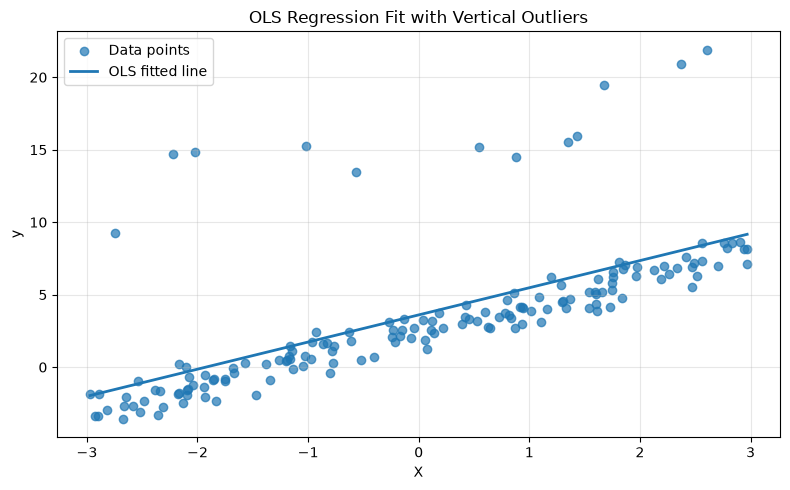

In [6]:
# Generate values for plotting the fitted line
X_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = ols_model.predict(X_line)

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    y,
    alpha=0.7,
    label="Data points"
)

plt.plot(
    X_line[:, 0],
    y_line,
    linewidth=2,
    label="OLS fitted line"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("OLS Regression Fit with Vertical Outliers")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3.

For each training instance, define the sample-specific weight

$$
a_i \in (0,1],
$$

where

$$
a_i =
\begin{cases}
0.05, & \text{if the sample is a known outlier},\\
1.0, & \text{if the sample is an inlier}.
\end{cases}
$$

Using the notation given,

$$
X \in \mathbb{R}^{N\times(D+1)},
\qquad
y \in \mathbb{R}^{N},
\qquad
w \in \mathbb{R}^{D+1},
$$

and

$$
A=\operatorname{diag}(a_1,a_2,\ldots,a_N)
\in
\mathbb{R}^{N\times N}.
$$

The weighted least-squares objective function can be written as

$$
J(w)
=
\frac{1}{2}
(y-Xw)^T A(y-Xw).
$$

Which after expanding,

$$
J(w)
=
\frac{1}{2}
\left[
y^TAy
-
2w^TX^TAy
+
w^TX^TAXw
\right].
$$

Differentiating with respect to (w),

$$
\nabla_w J(w)
=
-X^TAy+X^TAXw.
$$

At the minimum,

$$
\nabla_wJ(w)=0,
$$

therefore,

$$
X^TAXw=X^TAy.
$$

Multiplying by $(X^TAX)^{-1}$,

$$
\hat{w}_{\mathrm{WLS}}
=
(X^TAX)^{-1}X^TAy
$$


In [7]:
# Identify which training samples are known outliers
train_outlier_mask = np.isin(train_idx, outlier_idx)

# Sample-specific weights a_i
a = np.ones(len(train_idx))
a[train_outlier_mask] = 0.05

# A = diag(a_1, a_2, ..., a_N)
A = np.diag(a)

# Design matrix X with a leading column of ones for the intercept bias
X_wls = np.column_stack((
    np.ones(len(X_train)),
    X_train[:, 0]
))

# Target response vector
y_wls = y_train

In [8]:
# Closed-form WLS estimator:
# w_hat_WLS = (X^T A X)^(-1) X^T A y
w_WLS = (
    np.linalg.inv(X_wls.T @ A @ X_wls)
    @ X_wls.T
    @ A
    @ y_wls
)

print(f"WLS intercept (w0): {w_WLS[0]:.4f}")
print(f"WLS slope (w1):     {w_WLS[1]:.4f}")

WLS intercept (w0): 2.5180
WLS slope (w1):     1.8407


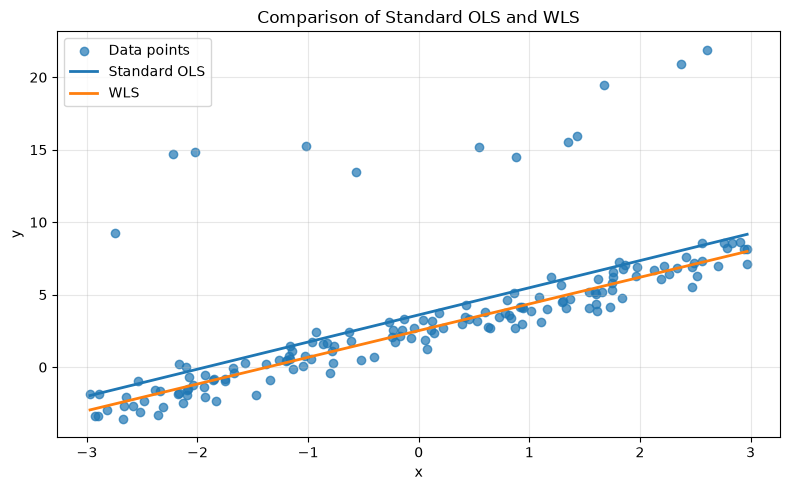

In [10]:
# Values used to draw the fitted lines
x_line = np.linspace(X.min(), X.max(), 200)

# Standard OLS fitted line
y_ols_line = w0 + w1 * x_line

# WLS fitted line
y_wls_line = w_WLS[0] + w_WLS[1] * x_line

plt.figure(figsize=(8, 5))

# Plot all data points with the same appearance
plt.scatter(
    X[:, 0],
    y,
    alpha=0.7,
    label="Data points"
)

# Standard OLS fitted line
plt.plot(
    x_line,
    y_ols_line,
    linewidth=2,
    label="Standard OLS"
)

# WLS fitted line
plt.plot(
    x_line,
    y_wls_line,
    linewidth=2,
    label="WLS"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of Standard OLS and WLS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The WLS fitted line is influenced less by the known outliers because their weights are reduced to $a_i=0.05,$ while all inliers maintain $a_i=1.0.$

Therefore, a known outlier contributes only

$$
0.05(y_i-w^Tx_i)^2
$$

to the weighted objective, compared with an inlier which has,

$$
(y_i-w^Tx_i)^2
$$

Therefore, the known outliers have less of an influence on $\hat{w}_{\mathrm{WLS}}$, so the WLS fitted line follows the trend more closely than the OLS fitted line.


## 4.

In [11]:
# Add nine pure noise variables
X_noise = rng.normal(size=(X.shape[0], 9))
X10 = np.column_stack([X, X_noise])

In [12]:
X10_train, X10_test, y10_train, y10_test = train_test_split(
    X10,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.model_selection import GridSearchCV

alpha_values = [1e-3, 1e-2, 1e-1, 1, 10]

ols_10 = LinearRegression()
ols_10.fit(X10_train, y10_train)

y10_pred_ols = ols_10.predict(X10_test)
mse_ols_10 = mean_squared_error(y10_test, y10_pred_ols)

print(f"OLS Test MSE: {mse_ols_10:.4f}")

OLS Test MSE: 4.8769


In [14]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid={"ridge__alpha": alpha_values},
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_grid.fit(X10_train, y10_train)

best_alpha_ridge = ridge_grid.best_params_["ridge__alpha"]
cv_mse_ridge = -ridge_grid.best_score_

print(f"Optimal Ridge alpha: {best_alpha_ridge}")
print(f"Ridge cross-validated MSE: {cv_mse_ridge:.4f}")

Optimal Ridge alpha: 10
Ridge cross-validated MSE: 18.2993


In [15]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid={"lasso__alpha": alpha_values},
    scoring="neg_mean_squared_error",
    cv=5
)

lasso_grid.fit(X10_train, y10_train)

best_alpha_lasso = lasso_grid.best_params_["lasso__alpha"]
cv_mse_lasso = -lasso_grid.best_score_

print(f"Optimal Lasso alpha: {best_alpha_lasso}")
print(f"Lasso cross-validated MSE: {cv_mse_lasso:.4f}")

Optimal Lasso alpha: 1
Lasso cross-validated MSE: 16.2273


The optimal regularization strengths selected using 5-fold cross-validation were

$$
\alpha_{\mathrm{Ridge}} = \text{10}
$$

and

$$
\alpha_{\mathrm{Lasso}} = \text{1}.
$$

The corresponding cross-validated Mean Squared Errors were

$$
MSE_{\mathrm{CV,Ridge}} = \text{18.2993}
$$

and

$$
MSE_{\mathrm{CV,Lasso}} = \text{16.2273}.
$$

## 5.

Ridge Regression applies the $L_2$ penalty

$$
\alpha \lVert w\rVert_2^2
=
\alpha\sum_{j=1}^{D}w_j^2,
$$

whereas Lasso Regression applies the $L_1$ penalty

$$
\alpha\lVert w\rVert_1
=
\alpha\sum_{j=1}^{D}|w_j|.
$$

The $L_2$ penalty used by Ridge reduces coefficient magnitudes toward zero but generally does not become exactly zero. Also, Ridge appears to retain all features while reducing the influence of less useful predictors.

The $L_1$ penalty used by Lasso can make some coefficients to become exactly zero. Therefore, Lasso can produce a sparse model containing only a subset of the original predictors.

When $D \gg N$ and only a small subset of features are genuinely informative, Lasso is preferable because its sparse solution can eliminate many irrelevant or noisy features by setting their coefficients exactly to zero.


In [16]:
ridge_best_model = ridge_grid.best_estimator_.named_steps["ridge"]
lasso_best_model = lasso_grid.best_estimator_.named_steps["lasso"]

print("Ridge coefficients:")
print(ridge_best_model.coef_)

print("\nLasso coefficients:")
print(lasso_best_model.coef_)

print(
    "\nNumber of zero Lasso coefficients:",
    np.sum(lasso_best_model.coef_ == 0)
)

Ridge coefficients:
[ 2.94454651 -0.47006812  0.07439794 -0.41285704  0.30999007  0.22744779
  0.05637689  0.04616594  0.17236713  0.32307471]

Lasso coefficients:
[ 2.22115816 -0.          0.         -0.          0.          0.
 -0.         -0.          0.          0.        ]

Number of zero Lasso coefficients: 9


## 6.

Standardized feature scaling transforms each feature according to

$$
z=\frac{x-\mu}{\sigma}.
$$

Ridge and Lasso penalize the magnitudes of the model weights directly. If the input features have different scales, the corresponding coefficients also operate on different scales.

A feature with very large numerical values may require only a small coefficient to have a large effect on the prediction, while a feature with small numerical values may require a much larger coefficient to produce the same effect. Since Ridge and Lasso penalize coefficient magnitude,
$\alpha\lVert w\rVert_2^2$  or  $\alpha\lVert w\rVert_1,$ features measured on smaller scales would be penalized more heavily because they require larger coefficients. Standardization gives each feature approximately $\mu=0$ and $\sigma=1,$ which makes the predictors be on a comparable scale. The regularization penalty can then act fairly over all coefficients rather than being influenced by the original measurement units of the features.


# Question 2 - Logistic Regression: Preprocessing, Interpretation and Evaluation



In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
X_num, y = make_classification(
n_samples=600,
n_features=4,
n_informative=3,
n_redundant=1,
class_sep=0.9,
weights=[0.68, 0.32],
flip_y=0.03,
random_state=21
)
df = pd.DataFrame(X_num, columns=["x1", "x2", "x3", "x4"])
rng = np.random.default_rng(21)
df["region"] = rng.choice(["north", "south", "east"], size=len(df))
df["device"] = rng.choice(["mobile", "desktop"], size=len(df))
df.loc[rng.choice(len(df), 25, replace=False), "x3"] = np.nan

## 1.

LogisticRegression expects numerical feature values because the model calculates a weighted linear combination of inputs, $z=w^Tx,$ before applying the logistic function. String-valued columns cannot directly be involved in these numerical operations, so passing them directly to LogisticRegression results in a runtime conversion error.

A basic LabelEncoder approach would convert categories into arbitrary integers, as an example strings like "north", "south" and "east" would be mapped to integers like {0, 1, 2}. 

This introduces an ordinal relationship between the categories. The model may then interpret category `2` as being larger in magnitude than category `1`, and category `1` as larger than category `0`, even though no ordering exists for regions.

It also introduces numerical distances that do not exist between categories. For example, the encoded distance between `0` and `2` is twice the distance between `0` and `1`, eventhough the original values do not have meaningful numerical distances.



## 2.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Separate numerical and categorical columns
numerical_features = ["x1", "x2", "x3", "x4"]
categorical_features = ["region", "device"]

X_train, X_test, y_train, y_test = train_test_split(
    df,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

logistic_pipeline.fit(X_train, y_train)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

Training samples: 480
Test samples: 120

Training class distribution:
0    0.670833
1    0.329167
Name: proportion, dtype: float64

Test class distribution:
0    0.675
1    0.325
Name: proportion, dtype: float64


## 3.

In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Logistic Regression pipeline using the required solver
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(solver="liblinear"))
])

# Hyperparameter search space
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"]
}

# 5-fold Stratified Cross-Validation
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid search optimized for F1-score
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1
)

# Perform grid search using only the training data
grid_search.fit(X_train, y_train)

# Extract the optimal parameters and score
best_C = grid_search.best_params_["classifier__C"]
best_penalty = grid_search.best_params_["classifier__penalty"]
best_cv_f1 = grid_search.best_score_

# Store the best fitted model for the next question
best_model = grid_search.best_estimator_

print(f"Best C: {best_C}")
print(f"Best penalty: {best_penalty}")
print(f"Best cross-validation F1-score: {best_cv_f1:.4f}")

Best C: 1
Best penalty: l1
Best cross-validation F1-score: 0.8148


As seen above, the optimal parameters selected were $C = \text{1}$,  $\text{penalty}$  = $l_1$ and the best cross-validation F1-score was $F1_{\mathrm{CV}} = \text{0.8148}.$

## 4.

In [9]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predict using the best model selected by GridSearchCV
y_pred = best_model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

Accuracy:  0.8583
Precision: 0.7895
Recall:    0.7692
F1-score:  0.7792

Confusion Matrix:
[[73  8]
 [ 9 30]]


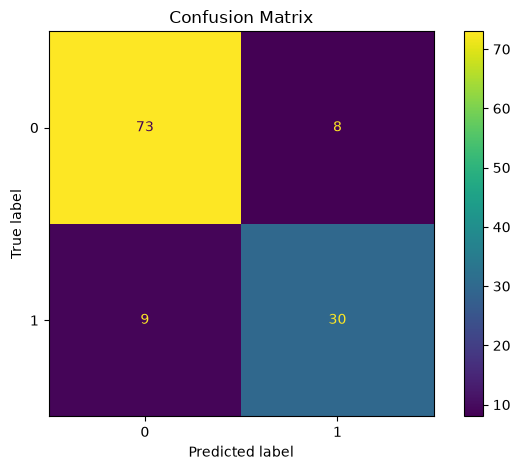

In [10]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Overall accuracy can be misleading for a class-imbalanced dataset because it gives equal importance to every correct prediction without considering how performance is distributed between the classes.

In the dataset where approximately 68% of the observations belong to the negative class and only 32% belong to the positive class. A classifier that predicts the majority class for most observations can show a high accuracy but still not identify many positive cases.

In this instance even a model that always predicts the negative class could obtain an accuracy close to 68% and end up having a recall of around zero for the positive class.

Therefore, the measure of accuracy could be misleading in such cases.


## 5.

In [11]:
# Obtain predicted probabilities for the positive class
y_prob = best_model.predict_proba(X_test)[:, 1]

# Predictions using the default threshold of 0.50
y_pred_050 = (y_prob >= 0.50).astype(int)

precision_050 = precision_score(y_test, y_pred_050)
recall_050 = recall_score(y_test, y_pred_050)

# Predictions using the lower threshold of 0.35
y_pred_035 = (y_prob >= 0.35).astype(int)

precision_035 = precision_score(y_test, y_pred_035)
recall_035 = recall_score(y_test, y_pred_035)

print("Threshold = 0.50")
print(f"Precision: {precision_050:.4f}")
print(f"Recall:    {recall_050:.4f}")

print("\nThreshold = 0.35")
print(f"Precision: {precision_035:.4f}")
print(f"Recall:    {recall_035:.4f}")

Threshold = 0.50
Precision: 0.7895
Recall:    0.7692

Threshold = 0.35
Precision: 0.6875
Recall:    0.8462


The number of positive observations increased when the classification threshold was decreased. We can identify that lowering the threshold made the model more likely to classify observations as positive. Here, we can see above that the recall increased from 0.7692 to 0.8462. this means that a greater portion of the actual positive cases were successfully identified. But the precision decreased from 0.7895 to 0.6875. This tells us that a larger portion of the predicted positive cases were false positives. This clearly represents the Precision-Recall trade-off.

A realistic application where lowering the threshold may be suitable is in a medical disease diagnosis. If the positive class represents the presence of a serious disease, a false negative could result in an affected patient being incorrectly considered healthy leading to further problems. Lowering the decision threshold increases recall and reduces the number of missed positive cases. The downside of this is there may be an increase in false positives and cause healthy patients to face additional testing, This still could be suitable when the danger of missing an actual disease much greater than the cost of additional testing.


## 6.
#### (a)

The logistic regression model is

$$
\ln\left(\frac{p}{1-p}\right)
=
-7.2+0.08x_1+1.4x_2.
$$

Let

$$
z=\ln\left(\frac{p}{1-p}\right).
$$

In exponent form,

$$
e^z=\frac{p}{1-p}.
$$

Multiplying both sides by (1-p),

$$
e^z(1-p)=p
$$
$$
e^z-e^zp=p
$$
$$
e^z=p(1+e^z)
$$

Solving for $p$,

$$
p=\frac{e^z}{1+e^z}.
$$

Dividing the numerator and denominator by $e^z$,

$$
\boxed{
p=\frac{1}{1+e^{-z}}
}.
$$

For a student with

$$
x_1=45,
\qquad
x_2=3.4,
$$



$$
z
= -7.2+0.08(45)+1.4(3.4)
$$
$$
z
= -7.2+3.6+4.76
$$

$$z = 1.16$$

Using the sigmoid function,

$$
p
=
\frac{1}{1+e^{-1.16}}
\approx 0.7613.
$$

Therefore,

$$
\boxed{p\approx0.7613}
$$

The student has a probability of approximately $76.13\%$ of passing with an A+.


#### (b)

For a target probability of $p=0.70$ and GPA of $3.4,$


$$
z
=
\ln\left(\frac{p}{1-p}\right).
$$
$$
z
=
\ln\left(\frac{0.70}{0.30}\right)
\ln\left(\frac{7}{3}\right)
\approx0.8473.
$$

Using the logistic regression model,

$$
0.8473
=
-7.2+0.08x_1+1.4(3.4).
$$

$$
0.8473
=
-7.2+0.08x_1+4.76.
$$
$$
0.8473=-2.44+0.08x_1,
$$
$$
0.08x_1=3.2873.
$$

Therefore,

$$
x_1
=
\frac{3.2873}{0.08}
\approx41.09.
$$

The required number of study hours to achieve a predicted probability of $0.70$ is approximately

$$
\boxed{x_1\approx41.09\text{ hours}}.
$$





# Question 3 - Optimization of Logistic Regression

In [12]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X, y = make_blobs(
n_samples=1200,
centers=[[-2.2,-0.5], [2.0, 1.2]],
cluster_std=[1.45, 1.65],
random_state=8
)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

## 1.

Let

$$
p_i=\sigma(w^Tx_i)
=
\frac{1}{1+e^{-w^Tx_i}}.
$$

The Binary Cross-Entropy loss is

$$
J(w)
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\ln p_i
+
(1-y_i)\ln(1-p_i)
\right].
$$

For a single sample,

$$
J_i(w)
=
-\left[
y_i\ln p_i
+
(1-y_i)\ln(1-p_i)
\right].
$$

Since

$$
p_i=\sigma(w^Tx_i),
$$

the derivative of the sigmoid with respect to its input is

$$
\frac{\partial p_i}{\partial (w^Tx_i)}
=
p_i(1-p_i).
$$

Differentiating the single-sample loss with respect to (w),

$$
\nabla_w J_i(w)
=
(p_i-y_i)x_i.
$$

Therefore, averaging over all (N) samples gives the gradient vector

$$
\boxed{\nabla J(w)
=
\frac{1}{N}
\sum_{i=1}^{N}
(p_i-y_i)x_i}
$$

Differentiating the gradient again to find the Hessian,

$$
\frac{\partial p_i}{\partial w}
=
p_i(1-p_i)x_i,
$$

the Hessian contribution from one sample is

$$
p_i(1-p_i)x_ix_i^T.
$$

Therefore,

$$
\boxed{
H
=
\frac{1}{N}
\sum_{i=1}^{N}
p_i(1-p_i)x_ix_i^T
}.
$$


## 2.

In [13]:
# Standardize features using the training set statistics
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add a leading column of ones for the bias term
X_train_aug = np.column_stack((
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
))

X_test_aug = np.column_stack((
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
))

In [14]:
def sigmoid(z):
    
    #sigmoid function.
    z = np.asarray(z)

    result = np.empty_like(z, dtype=float)

    positive = z >= 0
    negative = ~positive

    result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))

    exp_z = np.exp(z[negative])
    result[negative] = exp_z / (1.0 + exp_z)

    return result

In [15]:
def cross_entropy_loss(X, y, w):
    
    #Compute Binary Cross-Entropy loss.

    z = X @ w

    return np.mean(
        np.logaddexp(0, z) - y * z
    )

A direct implementation of Binary Cross-Entropy uses

$$
-y_i\ln(p_i)-(1-y_i)\ln(1-p_i).
$$

Problems occur when the predicted probability approaches either boundary. If

$$
p_i\rightarrow0,
$$

then

$$
\ln(p_i)\rightarrow-\infty,
$$

and when

$$
p_i\rightarrow1,
$$

then

$$
\ln(1-p_i)\rightarrow-\infty.
$$

The sigmoid output may be rounded exactly to (0) or (1) for very large-magnitude inputs. Directly evaluating these logarithms can therefore produce overflows

The probabilities could be clipped using a constant like

$$
\epsilon=10^{-15},
$$

so that

$$
p_i
\leftarrow
\min\left(
\max(p_i,\epsilon),
1-\epsilon
\right).
$$

This makes sure that $\ln(p_i)$ and $\ln(1-p_i)$ are not evaluated at zero.

Other than that, the Binary Cross-Entropy loss could be evaluated directly using

$$
J(w)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left[
\log(1+e^{z_i})-y_i z_i
\right],
$$

where $z_i=w^Tx_i$. The function `np.logaddexp(0, z)` evaluates the logarithmic term in a numerically stable manner and avoids unnecessary overflow or underflow.

## 3.

In [16]:
# Batch Gradient Descent settings
eta = 0.1
max_iterations = 300
tolerance = 1e-8

# Initialize weights to zero
w_bgd = np.zeros(X_train_aug.shape[1])

# Store loss values for later comparison plots
bgd_loss_history = []

for t in range(max_iterations):

    # Current probabilities
    p = sigmoid(X_train_aug @ w_bgd)

    # Gradient of BCE loss
    gradient = (
        X_train_aug.T @ (p - y_train)
    ) / len(y_train)

    # Update weights
    w_bgd = w_bgd - eta * gradient

    # Compute loss after the update
    current_loss = cross_entropy_loss(
        X_train_aug,
        y_train,
        w_bgd
    )

    bgd_loss_history.append(current_loss)

    # Early stopping
    if t > 0:
        loss_difference = abs(
            bgd_loss_history[-1] - bgd_loss_history[-2]
        )

        if loss_difference < tolerance:
            break

# Total number of completed iterations
bgd_iterations = t + 1

# Test-set prediction
test_probabilities = sigmoid(X_test_aug @ w_bgd)
y_test_pred_bgd = (test_probabilities >= 0.5).astype(int)

# Test accuracy
bgd_test_accuracy = np.mean(y_test_pred_bgd == y_test)

print("Final weights:", w_bgd)
print(f"Total iterations: {bgd_iterations}")
print(f"Final training loss: {bgd_loss_history[-1]:.8f}")
print(f"Test accuracy: {bgd_test_accuracy:.4f}")

Final weights: [0.07072889 2.80512255 0.91512962]
Total iterations: 300
Final training loss: 0.19065865
Test accuracy: 0.9292


## 4.

In [17]:
# Mini-Batch Gradient Descent settings
batch_size = 32
eta_mb = 0.05
max_epochs = 100

# Initialize weights to zero
w_mbgd = np.zeros(X_train_aug.shape[1])

# Store average training loss after each epoch
mbgd_loss_history = []

# Fixed random generator for reproducible shuffling
rng_mbgd = np.random.default_rng(42)

N_train = len(y_train)

for epoch in range(max_epochs):

    # Shuffle training indices at the beginning of each epoch
    indices = rng_mbgd.permutation(N_train)

    for start in range(0, N_train, batch_size):

        batch_idx = indices[start:start + batch_size]

        X_batch = X_train_aug[batch_idx]
        y_batch = y_train[batch_idx]

        # Predicted probabilities for the current mini-batch
        p_batch = sigmoid(X_batch @ w_mbgd)

        # Mini-batch gradient
        gradient = (
            X_batch.T @ (p_batch - y_batch)
        ) / len(y_batch)

        # Update weights
        w_mbgd = w_mbgd - eta_mb * gradient

    # Compute full training loss after each epoch
    epoch_loss = cross_entropy_loss(
        X_train_aug,
        y_train,
        w_mbgd
    )

    mbgd_loss_history.append(epoch_loss)

print("Final Mini-Batch GD weights:", w_mbgd)
print(f"Final training loss: {mbgd_loss_history[-1]:.8f}")

Final Mini-Batch GD weights: [0.16889763 4.48329376 1.22212118]
Final training loss: 0.15959809


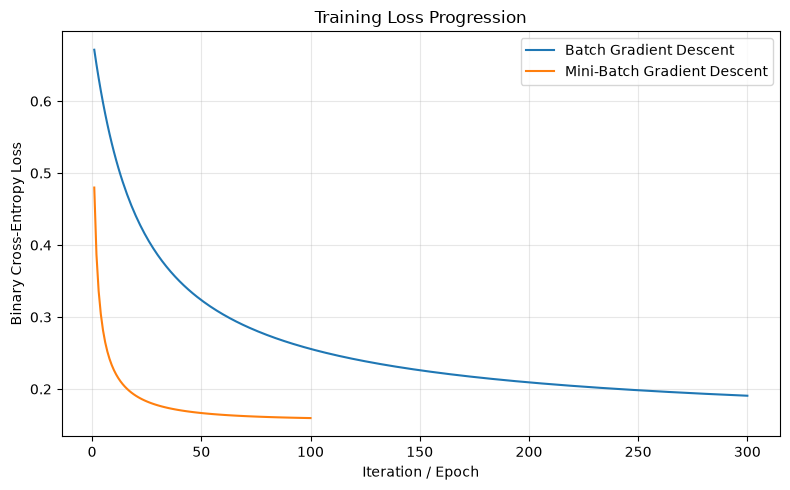

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(bgd_loss_history) + 1),
    bgd_loss_history,
    label="Batch Gradient Descent"
)

plt.plot(
    range(1, len(mbgd_loss_history) + 1),
    mbgd_loss_history,
    label="Mini-Batch Gradient Descent"
)

plt.xlabel("Iteration / Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss Progression")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5.

In [19]:
# Newton's Method settings
max_newton_iterations = 20
tolerance = 1e-8
damping = 1e-6

# Initialize weights to zero
w_newton = np.zeros(X_train_aug.shape[1])

# Store loss values for later comparison
newton_loss_history = []

N_train = len(y_train)
D_aug = X_train_aug.shape[1]

for t in range(max_newton_iterations):

    # Predicted probabilities
    p = sigmoid(X_train_aug @ w_newton)

    # Gradient
    gradient = (
        X_train_aug.T @ (p - y_train)
    ) / N_train

    # Diagonal terms of R
    r = p * (1 - p)

    # Hessian: H = (1/N) X^T R X
    H = (
        X_train_aug.T @
        (X_train_aug * r[:, np.newaxis])
    ) / N_train

    # Add damping term: H + 10^-6 I
    H_damped = H + damping * np.eye(D_aug)

    # Solve (H + 10^-6 I) d = gradient
    direction = np.linalg.solve(H_damped, gradient)

    # Newton update
    w_newton = w_newton - direction

    # Compute loss after update
    current_loss = cross_entropy_loss(
        X_train_aug,
        y_train,
        w_newton
    )

    newton_loss_history.append(current_loss)

    # Early stopping
    if t > 0:
        loss_difference = abs(
            newton_loss_history[-1] -
            newton_loss_history[-2]
        )

        if loss_difference < tolerance:
            break

# Total number of completed iterations
newton_iterations = t + 1

print("Final Newton weights:", w_newton)
print(f"Total iterations: {newton_iterations}")
print(f"Final training loss: {newton_loss_history[-1]:.8f}")

Final Newton weights: [0.21592304 5.28520196 1.39897014]
Total iterations: 8
Final training loss: 0.15728072


## 6.

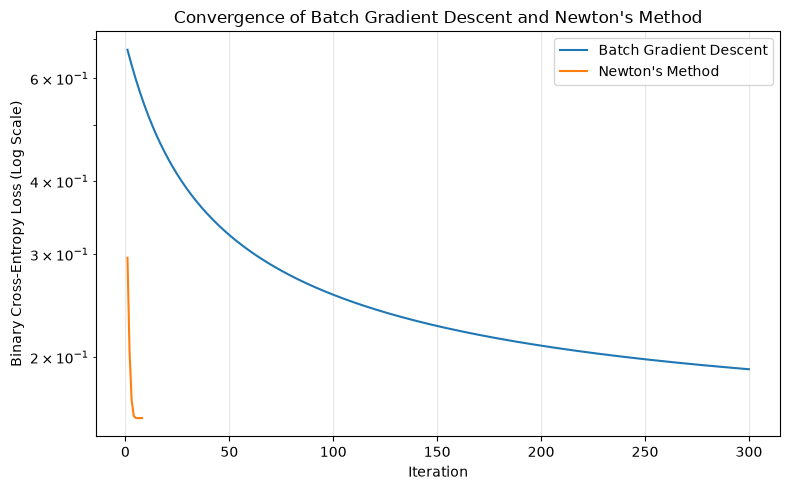

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(bgd_loss_history) + 1),
    bgd_loss_history,
    label="Batch Gradient Descent"
)

plt.plot(
    range(1, len(newton_loss_history) + 1),
    newton_loss_history,
    label="Newton's Method"
)

plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss (Log Scale)")
plt.title("Convergence of Batch Gradient Descent and Newton's Method")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Newton's Method generally converges in much fewer iterations than Batch Gradient Descent because it uses first-order gradient information and second-order curvature information from the Hessian.

Batch Gradient Descent updates the parameters using only $\nabla J(w),$ and has an approximate computational complexity of 

$$O(ND).$$

Newton's Method computes the Hessian and solves a linear system using the Hessian. Its computational complexity is approximately 

$$O(ND^2+D^3).$$

It can be clearly observed that Newton's Method performs more expensive updates, but it can converge in significantly less iterations because the Hessian provides information about the curvature of the loss surface. This is verified from our results where Batch Gradient descent required the total 300 iterations while Newton's Method converged in just 8 iterations.

Overall, Batch Gradient Descent has cheaper iterations and scales better, But Newton's Method provides faster convergence when the Hessian can be computed and solved efficiently.


## 7.

In [23]:
# Create an unscaled copy of the original dataset
X_unscaled = X.copy()

# Multiply the second feature by 100
X_unscaled[:, 1] = 100 * X_unscaled[:, 1]

# Using the same train/test split settings
X_train_unscaled, X_test_unscaled, y_train_unscaled, y_test_unscaled = train_test_split(
    X_unscaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Add the bias column, but NOT standardizing the features
X_train_unscaled_aug = np.column_stack((
    np.ones(X_train_unscaled.shape[0]),
    X_train_unscaled
))

X_test_unscaled_aug = np.column_stack((
    np.ones(X_test_unscaled.shape[0]),
    X_test_unscaled
))


# Batch Gradient Descent on the unscaled dataset
eta_unscaled = 0.1
max_iterations_unscaled = 300

w_unscaled = np.zeros(X_train_unscaled_aug.shape[1])
unscaled_loss_history = []

for t in range(max_iterations_unscaled):

    p = sigmoid(X_train_unscaled_aug @ w_unscaled)

    gradient = (
        X_train_unscaled_aug.T @ (p - y_train_unscaled)
    ) / len(y_train_unscaled)

    w_unscaled = w_unscaled - eta_unscaled * gradient

    current_loss = cross_entropy_loss(
        X_train_unscaled_aug,
        y_train_unscaled,
        w_unscaled
    )

    unscaled_loss_history.append(current_loss)

print("Final unscaled weights:", w_unscaled)
print(f"Final unscaled loss: {unscaled_loss_history[-1]:.8f}")

Final unscaled weights: [-1.21283186 21.32838417  6.51177739]
Final unscaled loss: 183.42960208


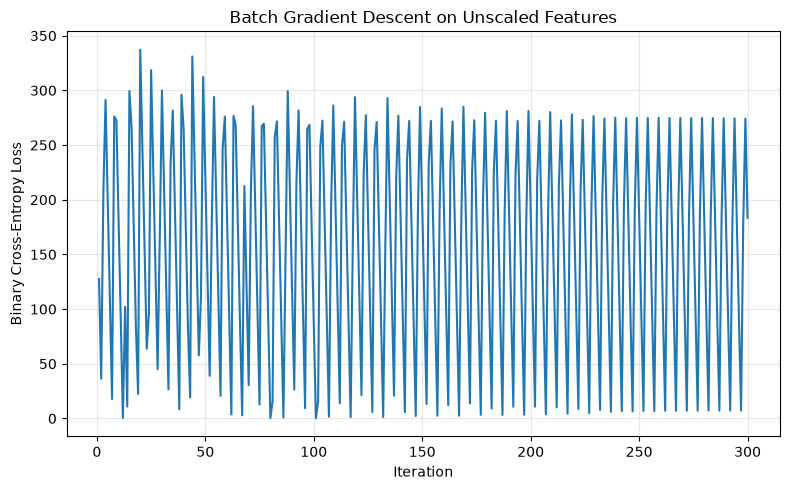

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(unscaled_loss_history) + 1),
    unscaled_loss_history
)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Batch Gradient Descent on Unscaled Features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Hessian at w = 0
p0 = np.full(len(y_train_unscaled), 0.5)
r0 = p0 * (1 - p0)

H_unscaled = (
    X_train_unscaled_aug.T
    @ (X_train_unscaled_aug * r0[:, np.newaxis])
) / len(y_train_unscaled)

eigenvalues = np.linalg.eigvalsh(H_unscaled)

condition_number = (
    eigenvalues.max() / eigenvalues.min()
)

H_scaled = (
    X_train_aug.T
    @ (X_train_aug * r0[:, np.newaxis])
) / len(y_train)

scaled_eigenvalues = np.linalg.eigvalsh(H_scaled)

scaled_condition_number = (
    scaled_eigenvalues.max() / scaled_eigenvalues.min()
)

print(f"Condition number of scaled Hessian:   {scaled_condition_number:.4e}")
print(f"Condition number of unscaled Hessian: {condition_number:.4e}")

Condition number of scaled Hessian:   2.4009e+00
Condition number of unscaled Hessian: 3.5959e+04


Multiplying the second feature by $100$ without standardization worsened the conditioning of the optimization problem. For the standardized dataset, the Hessian condition number was

$$
\kappa(H)_{\mathrm{scaled}} = 2.4009,
$$

whereas for the unscaled dataset it increased greatly to

$$
\kappa(H)_{\mathrm{unscaled}}
=
3.5959\times10^4.
$$

The much larger condition number indicates that the loss surface has highly unequal curvature in different parameter directions. As a result of this, the fixed learning rate of $\eta=0.1$ produces updates that are too large in the high-curvature direction, causing overshooting and unstable optimization. This behaviour is reflected in the final losses. 

With standardized features, Batch Gradient Descent obtained

$$
J(w)=0.19065865
$$

But in the unscaled dataset the final loss increased to

$$
J(w)=183.42960208,
$$

These results confirm that the unscaled optimization failed to converge reliably.

Two concrete remedies are:

1. Standardize the features using $z=\frac{x-\mu}{\sigma},$ which reduces differences in scale and improves the Hessian condition number.

2. Reduce the learning rate so that the parameter updates remain stable even along directions of high curvature.
